## **AI, Machine Learning & Python for Pharmaceutical Sciences**

### **Hands-On Colab Notebook - Module 04: Python Setup, Fundamentals & Live ML Demo**

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/) [![pandas](https://img.shields.io/badge/pandas-Latest-green)](https://pandas.pydata.org/) [![scikit-learn](https://img.shields.io/badge/scikit--learn-Latest-orange)](https://scikit-learn.org/) [![matplotlib](https://img.shields.io/badge/matplotlib-Latest-red)](https://matplotlib.org/) [![Google Colab](https://img.shields.io/badge/Google%20Colab-Ready-F9AB00?logo=googlecolab)](https://colab.research.google.com/) [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT) [![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-informational)](https://github.com/prakash-ukhalkar)

---

**Purpose:** Provide an executable, hands-on Python environment that mirrors the live demonstration in Module 04 of the session. Participants follow along in Google Colab, run each cell, and modify values to build intuition for Python and machine learning.

**Session Deliverables - what you build by the end of this notebook:**
1. Python variables, data types, lists, and dictionaries applied to pharmaceutical data
2. Reusable functions and for-loops for automated clinical trial patient screening
3. A complete supervised ML pipeline, data to trained model to new-compound prediction using Lipinski molecular descriptors and scikit-learn
4. Publication-quality visualisations: feature importance bar chart, confusion matrix, and sigmoidal dose-response curve
5. A five-algorithm comparison with Leave-One-Out cross-validation on the same compound dataset

**Scope Boundaries - what this notebook does NOT do:**

| Task | Deferred to |
|---|---|
| Full QSAR modelling with 100+ molecular descriptors | Production workflow with RDKit/DeepChem |
| Real ChEMBL dataset download and preprocessing | Post-session extension (see Section 4.2 note) |
| Deep learning / neural networks | TensorFlow/Keras tutorials (see Section 6 references) |
| GxP validation, 21 CFR Part 11 compliance | IT/QA team with validated Python environment |
| Model deployment / API serving | Flask/FastAPI or AWS SageMaker |

---

**Session:** AI, Machine Learning & Python for Pharmaceutical Sciences  
**Speaker:** Mr. [Prakash Ukhalkar](https://github.com/prakash-ukhalkar), Technical Expert, Assistant Professor, MCA, PCCoE, Pune  
**Organised by:** Spectratix Pharma Pvt. Ltd. & PharmaGyan Academy  
**Date:** 7th June 2026  
**Status:** Execution Ready

---

### **Session Roadmap (90-minute session)**

This is the **fourth and final module** in a four-module session:

1. Module 01 - Foundations of AI: What is AI? Narrow vs. General AI. The learning loop.
2. Module 02 - Machine Learning Essentials: Supervised/unsupervised/reinforcement learning. Key algorithms. Overfitting.
3. Module 03 - AI/ML in Pharmaceutical Sciences: AlphaFold, clinical trial design, drug discovery. Two industry case studies.
4. **Module 04 - Python Setup & Basics** ← *You are here*

---

**How to use this notebook:**
- Open [colab.research.google.com](https://colab.research.google.com), upload this file, and run cells top-to-bottom
- Click any code cell and press **Shift + Enter** to execute it
- Modify values where marked **Challenge** and re-run to build intuition
- All code is self-contained within each section

## 1. Environment Setup

### 1.1 Library Imports and Version Verification

**Purpose:** Confirm that all required libraries are available in the Colab runtime and print version numbers for reproducibility. All five libraries are pre-installed in Google Colab no `pip install` is needed for standard use.

**Key Points:**
- `pandas` - data manipulation; load, filter, reshape compound/patient datasets
- `numpy` - fast numerical arrays; underpins pandas and scikit-learn internally
- `scikit-learn` - the complete ML toolkit used throughout Sections 4 and 6
- `matplotlib` / `seaborn` - scientific plotting; all charts in this notebook use these two libraries
- If any import fails, run `!pip install <package_name>` in a new cell above this one
- **GxP note:** In a regulated environment, pin versions in `requirements.txt` and version-control with Git for audit traceability

### Check the environment

This cell imports the core libraries and prints their versions.

In [ ]:
# Verify core library versions
import sys
print(f"Python: {sys.version}")

import pandas as pd
import numpy as np
import matplotlib
import sklearn
import seaborn

print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"seaborn     : {seaborn.__version__}")
print("\nAll libraries loaded successfully.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas      : 2.2.2
numpy       : 2.0.2
matplotlib  : 3.10.0
scikit-learn: 1.6.1
seaborn     : 0.13.2

All libraries loaded successfully.


## 2. Python Fundamentals

### 2.1 Variables, Data Types, Lists, and Dictionaries

**Purpose:** Introduce the four core Python data structures most commonly used in pharmaceutical informatics. All examples use real pharmaceutical context such as drug names, molecular weights, dose series, and compound property dictionaries.

**Key Points:**
- Python is **dynamically typed**, no type declarations required; Python infers type on assignment
- **Strings** store drug names, SMILES notation, compound IDs, regulatory status labels
- **Floats** store continuous measurements: molecular weight (Da), LogP, IC50, EC50, biomarker concentrations
- **Booleans** store binary flags: FDA approval status, trial eligibility, toxicity flag
- **Lists** store ordered sequences: dose series, patient ID lists, time points, screening results
- **Dictionaries** store compound property records equivalent to a row in a database table; convert directly to a pandas DataFrame row
- **List comprehension** is idiomatic Python for one-line filtering equivalent to Excel's `FILTER()` function but faster and more flexible
- **F-strings** produce formatted output suitable for audit logs, report generation, and labelled plot annotations

**Pharmaceutical mapping:**

| Python Structure | Pharmaceutical Use |
|---|---|
| `str` | Drug name, SMILES, compound ID, adverse event code |
| `float` | MW, LogP, IC50, EC50, biomarker level |
| `bool` | Approval status, toxicity flag, trial eligibility |
| `list` | Dose series, patient IDs, time point vector |
| `dict` | Compound property record, patient metadata row |

### Work with basic Python data

This example stores drug facts in variables, a list, and a dictionary.

In [ ]:
# --- VARIABLES AND DATA TYPES ---

drug_name   = "Ibuprofen"     # string  - drug names, SMILES, compound IDs
mol_weight  = 206.28          # float   - molecular weight (Daltons)
is_approved = True            # boolean - FDA approval status
num_trials  = 3               # integer - number of clinical trials

print(f"Drug       : {drug_name}")
print(f"MW         : {mol_weight} Da")
print(f"Approved   : {is_approved}")
print(f"Trials     : {num_trials}")
print()

# --- LISTS ---
# Ordered, mutable collection - ideal for dose series, time points, patient IDs
dosages = [200, 400, 600, 800]        # ibuprofen dose range in mg
print(f"Dosages         : {dosages}")
print(f"First dose      : {dosages[0]} mg")
print(f"Last dose       : {dosages[-1]} mg")

# List comprehension - one-line filter
# Read as: 'give me d for every d in dosages where d is >= 400'
therapeutic_range = [d for d in dosages if d >= 400]
print(f"Therapeutic range: {therapeutic_range} mg")
print()

# --- DICTIONARIES ---
# Key-value pairs - ideal for compound property storage
drug_info = {
    "name"       : "Atorvastatin",
    "class"      : "Statin",
    "target"     : "HMG-CoA reductase",
    "mol_weight" : 558.64,
    "logP"       : 6.36,
    "is_approved": True
}

print(f"Drug name  : {drug_info['name']}")
print(f"Target     : {drug_info['target']}")
print(f"MW         : {drug_info['mol_weight']} Da")

# F-strings for formatted output
print(f"\n{drug_info['name']} | MW: {drug_info['mol_weight']} Da | LogP: {drug_info['logP']}")

Drug       : Ibuprofen
MW         : 206.28 Da
Approved   : True
Trials     : 3

Dosages         : [200, 400, 600, 800]
First dose      : 200 mg
Last dose       : 800 mg
Therapeutic range: [400, 600, 800] mg

Drug name  : Atorvastatin
Target     : HMG-CoA reductase
MW         : 558.64 Da

Atorvastatin | MW: 558.64 Da | LogP: 6.36


> **Challenge:** Change `drug_name` to `"Aspirin"` and `mol_weight` to `180.16`, then re-run.  
> Then add a new key `"dose_mg"` to `drug_info` with a value of `500` and print it using an f-string.

## 3. Functions, Loops & Control Flow

### 3.1 Automated Clinical Trial Patient Screening

**Purpose:** Demonstrate reusable functions (`def`), conditional logic (`if/elif/else`), and `for`-loop iteration on a list of patient records implementing a real clinical trial inclusion/exclusion screening pipeline. This is a miniature version of what CROs and sponsors build for automated patient eligibility checking.

**Key Points:**
- `def` creates a named, reusable function; write logic once, call it across any number of patients
- The BMI formula $BMI = \dfrac{weight\,(kg)}{height\,(m)^2}$ is a standard inclusion criterion many trials exclude patients below 18.5 or above 35
- `**` is Python's exponentiation operator; `height_m ** 2` means `height_m` squared
- `if / elif / else` chains implement decision-tree logic; map directly to your protocol's inclusion/exclusion criteria
- The patient dataset is a **list of dictionaries** - the most natural Python structure before loading into pandas
- `.append()` builds the eligible/ineligible lists incrementally inside the loop
- **Docstrings** (`"""..."""`) document function purpose, parameters, and return values mandatory in GxP Python scripts for audit and validation

**Production scaling note:**

| Demo (this cell) | Production |
|---|---|
| 5 patients in a Python list | 50,000 patients in `patients.xlsx` |
| Manual list construction | `df = pd.read_excel('patients.xlsx')` |
| `for p in patients` loop | `df.apply(lambda row: classify_bmi(...), axis=1)` |
| Print output | Write to `eligible_patients.csv` |
| ~instant | ~2–5 seconds for 50,000 rows |

**Reference:** WHO BMI Classification: https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight

### Screen example patients

A function calculates BMI, then a loop applies eligibility rules to every patient.

In [ ]:
# --- FUNCTION: BMI CLASSIFICATION ---

def classify_bmi(weight_kg, height_m):
    """
    Classify BMI for clinical trial screening.

    Parameters
    ----------
    weight_kg : float
        Patient weight in kilograms.
    height_m : float
        Patient height in metres.

    Returns
    -------
    tuple : (category: str, bmi: float)
    """
    bmi = weight_kg / (height_m ** 2)   # Standard BMI formula

    if bmi < 18.5:
        category = "Underweight"
    elif bmi < 25.0:
        category = "Normal weight"
    elif bmi < 30.0:
        category = "Overweight"
    else:
        category = "Obese"

    return category, round(bmi, 2)


# --- PATIENT DATASET ---
# List of dictionaries - each dict is one patient record
patients = [
    {"id": "P001", "weight": 70,  "height": 1.72, "age": 45},
    {"id": "P002", "weight": 95,  "height": 1.68, "age": 52},
    {"id": "P003", "weight": 55,  "height": 1.65, "age": 38},
    {"id": "P004", "weight": 88,  "height": 1.80, "age": 60},
    {"id": "P005", "weight": 102, "height": 1.75, "age": 47},
]

# --- TRIAL ELIGIBILITY SCREENING ---
# Inclusion criteria: BMI between 20 and 32, age 18-55
eligible   = []
ineligible = []

print(f"{'ID':<6} {'Weight':>8} {'Height':>8} {'BMI':>8} {'Category':<16} {'Eligible'}")
print("-" * 62)

for p in patients:
    category, bmi = classify_bmi(p["weight"], p["height"])
    meets_bmi = 20.0 <= bmi <= 32.0
    meets_age = 18 <= p["age"] <= 55

    if meets_bmi and meets_age:
        eligible.append(p["id"])
        flag = "YES"
    else:
        ineligible.append(p["id"])
        flag = "NO"

    print(f"{p['id']:<6} {p['weight']:>7}kg {p['height']:>7}m {bmi:>8} {category:<16} {flag}")

print()
print(f"Eligible patients  : {eligible}")
print(f"Ineligible patients: {ineligible}")
print(f"\nScreening complete: {len(eligible)}/{len(patients)} patients eligible")

ID       Weight   Height      BMI Category         Eligible
--------------------------------------------------------------
P001        70kg    1.72m    23.66 Normal weight    YES
P002        95kg    1.68m    33.66 Obese            NO
P003        55kg    1.65m     20.2 Normal weight    YES
P004        88kg     1.8m    27.16 Overweight       NO
P005       102kg    1.75m    33.31 Obese            NO

Eligible patients  : ['P001', 'P003']
Ineligible patients: ['P002', 'P004', 'P005']

Screening complete: 2/5 patients eligible


> **Challenge:** Modify the inclusion criteria to require BMI between **22 and 30** (stricter metabolic window).  
> How many patients remain eligible? Add a third criterion: `p["age"] >= 25` and re-run.

## 4. Live Demo - Drug Activity Prediction

### 4.1 Overview: From Data to Trained Model in ~15 Lines

**Purpose:** Build a complete, end-to-end supervised machine learning pipeline that predicts whether a new drug candidate is **biologically active** based on four Lipinski molecular descriptors. This is the centrepiece of the session demonstrating that a production-ready ML workflow requires far fewer lines of code than most pharmaceutical professionals expect.

**Algorithm:** Random Forest Classifier: an ensemble of 100 decision trees that votes on each prediction. Industry workhorse for ADMET prediction; robust to noise, handles small datasets reasonably well.

**Input Features: Lipinski Rule of Five Descriptors:**

| Feature | Description | Rule of Five Threshold |
|---|---|---|
| `mol_weight` | Molecular weight (Daltons) | ≤ 500 Da |
| `logP` | Lipophilicity - membrane permeability | ≤ 5 |
| `h_donors` | Hydrogen bond donors | ≤ 5 |
| `h_acceptors` | Hydrogen bond acceptors | ≤ 10 |

**Pipeline Steps in This Section:**

| Step | Sub-section | What Happens |
|---|---|---|
| 1 | 4.1 Imports | Load pandas, numpy, scikit-learn, matplotlib |
| 2 | 4.2 Dataset | Build 10-compound dataset with Lipinski descriptors and activity labels |
| 3 | 4.3 EDA | Visualise descriptor distributions split by active/inactive |
| 4 | 4.4 Split | Separate features (X) from labels (y); 70/30 train-test partition |
| 5 | 4.5 Train | `model.fit()` - 100 decision trees learn the activity patterns |
| 6 | 4.6 Evaluate | Accuracy, precision, recall, F1; confusion matrix plot |
| 7 | 4.7 Explainability | Feature importance - which descriptor drove the predictions |
| 8 | 4.8 Predict | Feed unseen compound; receive Active/Inactive + confidence probability |

**Limitation acknowledgement:** This demo uses 10 compounds for teaching clarity. Production QSAR models use thousands to millions of data points (e.g., ChEMBL: 2.4 million bioactivity records). The pipeline structure is identical at any scale.

**Reference:** Lipinski, C. A. (2004). Lead- and drug-like compounds: the rule-of-five revolution. *Drug Discovery Today: Technologies*, 1(4), 337–341.

### 4.2 Imports

**Purpose:** Load the five libraries required for the ML pipeline. `RANDOM_STATE = 42` is set once here and passed to every stochastic operation in this section, ensuring fully reproducible results, a requirement in both research and GxP regulated workflows.

**Key library roles:**
- `pandas`: tabular data as DataFrames (equivalent to a programmable Excel table)
- `numpy`: fast array operations; provides `np.random.seed()` for global reproducibility
- `sklearn.ensemble.RandomForestClassifier`: the prediction algorithm
- `sklearn.model_selection.train_test_split`: partition data into training and test sets
- `sklearn.metrics`: accuracy, classification report, confusion matrix

### Install dependencies once (outside the notebook)

This project deliberately does **not** install packages while a notebook is running.
From the repository root, create a virtual environment and run `pip install -r
requirements.txt`. Keeping installation outside the notebook makes runs predictable.

### Import packages and set a repeatable seed

Imports are collected in one place; the fixed seed makes random operations repeatable.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import LeaveOneOut, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
print("Imports successful. Random seed set to 42.")


Imports successful.


### 4.3 Dataset Construction

**Purpose:** Build the compound activity dataset as a pandas DataFrame. Each row is one compound; columns are the four Lipinski descriptors plus the binary activity label (`active = 1` means the compound showed biological activity in a biochemical assay; `active = 0` means inactive).

**Key Points:**
- `pd.DataFrame(data)` converts a dictionary of lists into a tabular DataFrame, the standard way to build small datasets in Python
- `active` is the **label** (what we want to predict); the four descriptor columns are the **features** (the inputs the model learns from)
- In a real workflow this cell is replaced by: `df = pd.read_csv('chembl_activity_data.csv')`, the rest of the pipeline is unchanged
- Examining class balance (`active.sum()` vs `(active == 0).sum()`) is the first step in any classification project; imbalanced datasets require stratified splits or resampling

**Production data source:** [ChEMBL](https://www.ebi.ac.uk/chembl/) 2.4 million bioactivity records, free download, same Lipinski descriptors pre-calculated

### Load and validate the teaching dataset

The CSV is version-controlled. Validation stops early if essential columns or values are missing.

In [ ]:
DATA_PATH = Path("data/raw/compound_activity_demo.csv")
df = pd.read_csv(DATA_PATH)

required_columns = {"compound", "mol_weight", "logP", "h_donors", "h_acceptors", "active"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing columns: {sorted(missing_columns)}")
if df.isna().any().any():
    raise ValueError("Dataset contains missing values; clean it before modelling.")

print(f"Dataset shape: {df.shape}")
print(f"Active compounds: {df['active'].sum()}")
print(f"Inactive compounds: {(df['active'] == 0).sum()}")
display(df.head())


Dataset shape: (10, 6)
Active compounds  : 5
Inactive compounds: 5

compound  mol_weight  logP  h_donors  h_acceptors  active
     C01       206.3   2.1         1            3       1
     C02       310.4   3.8         2            4       1
     C03       180.2   1.2         1            2       0
     C04       425.5   4.9         3            6       1
     C05       290.1   3.2         2            4       1
     C06       512.7   5.8         4            8       0
     C07       158.9   0.9         0            1       0
     C08       380.3   4.2         2            5       1
     C09       245.6   2.7         1            3       0
     C10       470.2   5.1         3            7       0


### 4.4 Exploratory Data Analysis (EDA)

**Purpose:** Visualise the distribution of each molecular descriptor for active vs. inactive compounds before training. EDA catches data quality issues, identifies class-separating patterns, and informs feature selection, it should precede every modelling exercise.

**Key Points:**
- Descriptor distributions that differ between active and inactive compounds signal predictive value
- `df.describe()` reports count, mean, std, min, quartiles, and max, the first statistical overview of any new dataset
- Overlapping histograms with alpha blending show both distributions without hiding either
- Green = Active, Red = Inactive (consistent throughout this notebook)

### Explore descriptors before modelling

Summary statistics and histograms show patterns worth investigating; they do not prove causality.

Descriptive statistics:
       mol_weight   logP  h_donors  h_acceptors
count       10.00  10.00     10.00        10.00
mean       318.02   3.39      1.90         4.30
std        124.44   1.67      1.20         2.21
min        158.90   0.90      0.00         1.00
25%        216.12   2.25      1.00         3.00
50%        300.25   3.50      2.00         4.00
75%        414.20   4.73      2.75         5.75
max        512.70   5.80      4.00         8.00



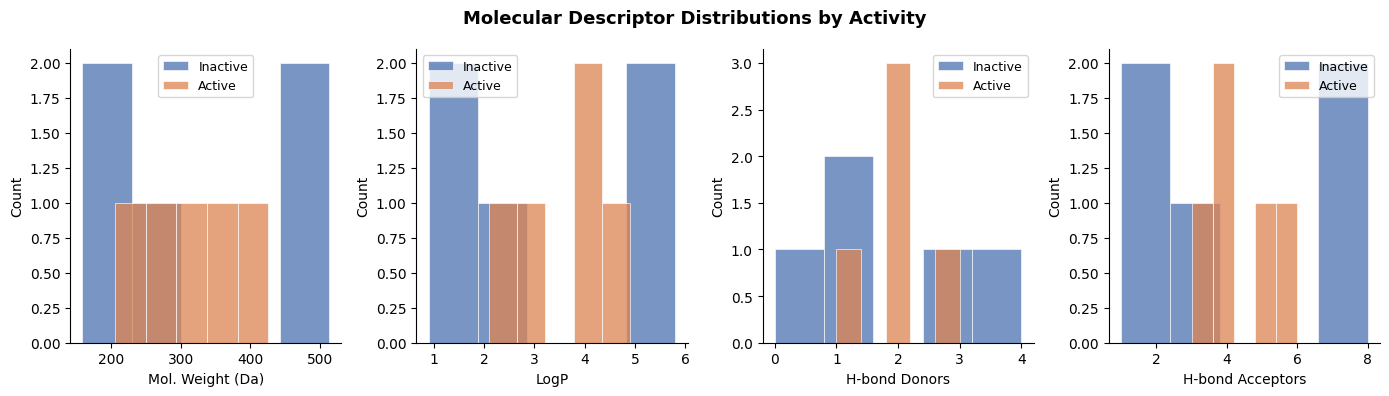

In [ ]:
print("Descriptive statistics:")
print(df[["mol_weight", "logP", "h_donors", "h_acceptors"]].describe().round(2))
print()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Molecular Descriptor Distributions by Activity", fontsize=13, fontweight="bold")

plot_features = ["mol_weight", "logP", "h_donors", "h_acceptors"]
x_labels = ["Mol. Weight (Da)", "LogP", "H-bond Donors", "H-bond Acceptors"]

# Colorblind-friendly blue/orange pair (seaborn "deep" palette)
# Blue = Inactive, Orange = Active — maximally distinct on screen and in print
palette = {0: "#4C72B0", 1: "#DD8452"}

for ax, feat, xlabel in zip(axes, plot_features, x_labels):
    for label, grp in df.groupby("active"):
        ax.hist(
            grp[feat],
            bins=5,
            alpha=0.75,
            label="Active" if label == 1 else "Inactive",
            color=palette[label],
            edgecolor="white",
            linewidth=0.6,
        )
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


### 4.5 Feature / Label Split & Train-Test Partition

**Purpose:** Separate the feature matrix `X` from the label vector `y`, then partition the data into a training set (70%) and a held-out test set (30%). The model never sees the test set during training - it is used only for final evaluation.

**Key Points:**
- `X` (capital) is the feature matrix - a 2D array of descriptor values; shape: (n_samples, n_features)
- `y` (lowercase) is the label vector - a 1D array of 0/1 activity labels; shape: (n_samples,)
- `test_size=0.3` reserves 30% of rows as a held-out evaluation set - standard practice is 20–30%
- `random_state=42` guarantees the same train/test split on every run, ensuring reproducibility - always set in research and GxP workflows
- This separation directly parallels a clinical trial design: the training set is your development cohort; the test set is your external validation cohort

### Define inputs and hold out test data

`X` contains descriptors and `y` the activity labels. Stratification keeps class balance in both splits.

In [ ]:
FEATURES = ["mol_weight", "logP", "h_donors", "h_acceptors"]

X = df[FEATURES]     # Feature matrix  - the inputs
y = df["active"]     # Label vector     - what we predict

# 70% training, 30% test
# random_state=42 ensures reproducibility - same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 7
Test samples     : 3


### 4.6 Model Training - Random Forest

**Purpose:** Instantiate a Random Forest classifier and train it on the training data. `model.fit()` is the single line where all the learning happens, 100 decision trees are built in parallel, each trained on a random bootstrap sample of the training rows and a random subset of the features.

**Key Points:**
- `n_estimators=100`: 100 independent decision trees; majority vote determines the final prediction
- `max_depth=None`: trees grow until all leaves are pure (every leaf contains only one class); suitable for small datasets where overfitting risk is low
- `random_state=42`: controls the random bootstrap sampling and feature selection within the forest; set for reproducibility
- The intuition: imagine asking 100 medicinal chemists to independently predict activity. Each looks at different molecular features. You take the majority vote. That is a Random Forest.
- `model.fit()` on 7 training samples with 4 features completes in milliseconds; the same API handles millions of samples, only the runtime changes

**Reference:** Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.

### Train a baseline random-forest model

The model learns from training data only. This very small dataset is for teaching, not production use.

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,        # 100 decision trees in the ensemble
    max_depth=None,          # Trees grow until leaves are pure
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

print("Model trained.")
print(f"Number of trees : {model.n_estimators}")
print(f"Number of features used: {model.n_features_in_}")

Model trained.
Number of trees : 100
Number of features used: 4


### 4.7 Model Evaluation

**Purpose:** Apply the trained model to the held-out test set and measure prediction quality. Report accuracy, precision, recall, and F1-score per class, and plot the confusion matrix.

**Key Points:**
- `model.predict(X_test)` generates class predictions (0 or 1) for each test compound
- **Accuracy** = proportion of correct predictions; simple but insufficient alone for drug datasets
- **Precision** = of all compounds predicted Active, what fraction truly are? (controls false positives, compounds entering synthesis that are actually inactive)
- **Recall / Sensitivity** = of all truly Active compounds, what fraction did the model find? (controls false negatives, active compounds missed)
- **F1-score** = harmonic mean of precision and recall; preferred metric when class balance is imperfect
- **Confusion matrix** visually separates true positives, false positives, true negatives, false negatives
- **GxP note:** Accuracy alone is insufficient for regulatory submissions. Always report AUC-ROC, precision-recall curve, and Matthews Correlation Coefficient (MCC) for drug activity datasets

**Reference:** Scikit-learn metrics guide: https://scikit-learn.org/stable/modules/model_evaluation.html

### Evaluate on unseen test compounds

Compare predictions with held-out labels. Metrics are unstable here because the test set has only three compounds.

Test Accuracy: 66.7%

Classification Report:
              precision    recall  f1-score   support

    Inactive       1.00      0.50      0.67         2
      Active       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



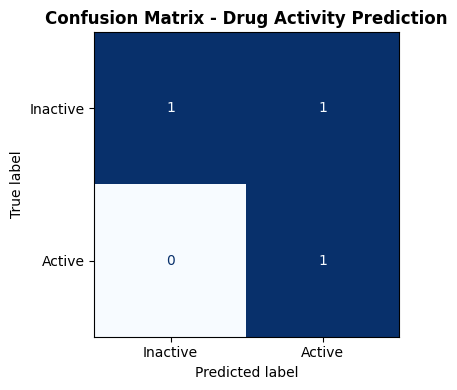


Note: This demo uses only 10 compounds. Production models use thousands of
data points (e.g., ChEMBL - 2.4 million bioactivity records). The pipeline
structure above scales directly to production datasets.


In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.1%}")
print()
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    labels=[0, 1],
    target_names=["Inactive", "Active"],
    zero_division=0
))

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Inactive", "Active"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix - Drug Activity Prediction", fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("Note: This demo uses only 10 compounds. Production models use thousands of")
print("data points (e.g., ChEMBL - 2.4 million bioactivity records). The pipeline")
print("structure above scales directly to production datasets.")

### 4.8 Feature Importance & Explainability

**Purpose:** Identify which molecular descriptor contributed most to the model's predictions. Feature importance is the first step toward model explainability, a regulatory requirement for AI tools used in GxP-regulated pharmaceutical processes (EMA Reflection Paper on ML, 2023).

**Key Points:**
- `model.feature_importances_` returns the mean decrease in node impurity (Gini impurity) for each feature, averaged across all 100 trees
- Higher value = more information provided by that descriptor when splitting data at tree nodes
- The top feature tells you which molecular property most strongly separates active from inactive compounds in this dataset
- **Explainability tools for production:** SHAP (SHapley Additive exPlanations) and LIME provide per-prediction explanations - not just global importance. Both work with scikit-learn Random Forests.
- **Regulatory implication:** An EMA or FDA reviewer asking "why did your model predict this compound as toxic?" requires an explainability answer. Feature importance charts and SHAP plots are the accepted responses.

**Reference:** Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 2017*. https://arxiv.org/abs/1705.07874

### Inspect feature importance

Importance scores are model-specific hints, not proof that a descriptor causes activity.

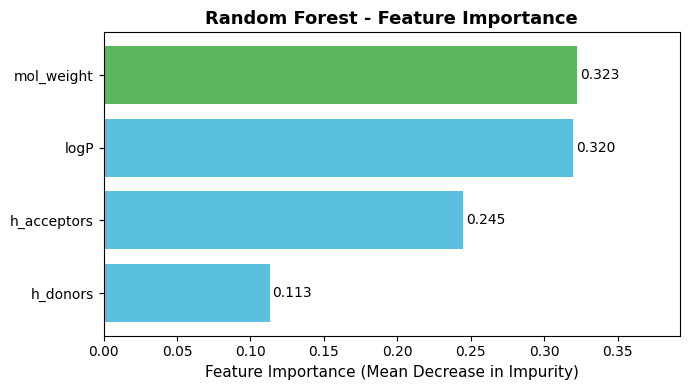

Most important descriptor: mol_weight
This means the model relied most heavily on this property when classifying compounds.


In [ ]:
importances = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    importances.index,
    importances.values,
    color=["#5cb85c" if v == importances.max() else "#5bc0de" for v in importances.values]
)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=11)
ax.set_title("Random Forest - Feature Importance", fontsize=13, fontweight="bold")

for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

ax.set_xlim(0, importances.max() + 0.07)
plt.tight_layout()
plt.show()

top_feature = importances.idxmax()
print(f"Most important descriptor: {top_feature}")
print("This means the model relied most heavily on this property when classifying compounds.")

### 4.9 Virtual Screening - Predict an Unseen Compound

**Purpose:** Demonstrate the inference step - feeding a compound the model has never seen and receiving an activity prediction with a confidence probability. This is the payoff of the entire pipeline: in production, you feed 1 million virtual compounds and rank them by `P(Active)`.

**Key Points:**
- `model.predict()` returns the class label (0 = Inactive, 1 = Active)
- `model.predict_proba()` returns `[P(Inactive), P(Active)]` the probability of each class; more informative than a binary label
- **Lipinski Rule of Five check** is applied alongside the ML prediction, a compound can be predicted active but still fail drug-likeness criteria
- **Production application:** In Insilico Medicine's IPF drug discovery (Case Study 1), the trained model ranked millions of AI-generated molecular structures by predicted binding affinity. Human chemists then synthesised and tested the top-ranked candidates - reducing wet-lab experiments by 10–100x.
- `predict_proba` confidence of 60% vs. 95% carries very different decision weight - always report confidence alongside the binary prediction

### Predict a new candidate

Change descriptors to explore the pipeline. The Lipinski check is a heuristic, not an ADME or safety assessment.

In [ ]:
# Define a new candidate compound - modify these values and re-run
new_compound = pd.DataFrame(
    [[198.0, 2.3, 1, 3]],
    columns=FEATURES
)

pred        = model.predict(new_compound)[0]
pred_proba  = model.predict_proba(new_compound)[0]   # [prob_inactive, prob_active]

label = "ACTIVE" if pred == 1 else "INACTIVE"

print("New Compound Properties")
print("-" * 40)
for feat, val in zip(FEATURES, new_compound.iloc[0]):
    print(f"  {feat:<14}: {val}")
print("-" * 40)
print(f"Prediction     : {label}")
print(f"Confidence     : {max(pred_proba):.1%}")
print(f"P(Active)      : {pred_proba[1]:.1%}")
print(f"P(Inactive)    : {pred_proba[0]:.1%}")

# Lipinski Rule of Five check
mw, logP, hd, ha = new_compound.iloc[0]
ro5_pass = (mw <= 500) and (logP <= 5) and (hd <= 5) and (ha <= 10)
print(f"\nLipinski RO5   : {'PASS' if ro5_pass else 'FAIL'}")
print("\nIn production: feed 1 million virtual compounds, rank by P(Active),")
print("then prioritise the top 1,000 for physical synthesis and assay testing.")

New Compound Properties
----------------------------------------
  mol_weight    : 198.0
  logP          : 2.3
  h_donors      : 1.0
  h_acceptors   : 3.0
----------------------------------------
Prediction     : ACTIVE
Confidence     : 81.0%
P(Active)      : 81.0%
P(Inactive)    : 19.0%

Lipinski RO5   : PASS

In production: feed 1 million virtual compounds, rank by P(Active),
then prioritise the top 1,000 for physical synthesis and assay testing.


> **Challenge - Virtual Screening Experiments:**  
> 1. Set `mol_weight = 520` and `logP = 6.0` (violates Lipinski RO5 on two counts) - does the prediction change? Does the confidence change?  
> 2. Set `mol_weight = 280`, `logP = 3.0`, `h_donors = 1`, `h_acceptors = 3` - what happens to `P(Active)`?  
> 3. Change `n_estimators` from `100` to `10` in Section 4.6 and re-run everything. Does accuracy and confidence change? Why?

## 5. Dose-Response Curve - Hill Equation

### 5.1 Pharmacodynamic Modelling with Python

**Purpose:** Generate publication-quality sigmoidal dose-response curves for three compounds using the Hill equation, demonstrating how Python replaces specialised pharmacology software (GraphPad Prism, SigmaPlot) with free, scriptable, reproducible code.

**The Hill (Emax) Equation:**

$$E = E_{max} \cdot \dfrac{D^n}{EC_{50}^n + D^n}$$

| Parameter | Description |
|---|---|
| $E$ | Observed effect at dose $D$ (%) |
| $E_{max}$ | Maximum possible effect |
| $EC_{50}$ | Dose producing 50% of $E_{max}$, the potency measure |
| $n$ | Hill coefficient, steepness of the curve (cooperativity) |

**Key Points:**
- `np.logspace(-2, 3, 200)` generates 200 dose points from 0.01 to 1000 mg/kg on a log scale, standard for dose-response plots
- `ax.semilogx()` plots the x-axis on a log scale, which is the pharmacological convention
- Lower `EC50` = more potent (drug reaches half-maximal effect at lower dose)
- Hill coefficient `n > 1` produces a steeper curve (positive cooperativity common for receptor-mediated responses)
- This same function models IC50 curves, MIC curves, and inhibition assay data

**Reference:** Hill, A. V. (1910). The possible effects of the aggregation of the molecules of haemoglobin on its dissociation curves. *Journal of Physiology*, 40(Suppl), iv–vii.

### Plot dose-response curves

The Hill equation maps dose to expected effect. Lower EC50 implies greater potency in this illustrative model.

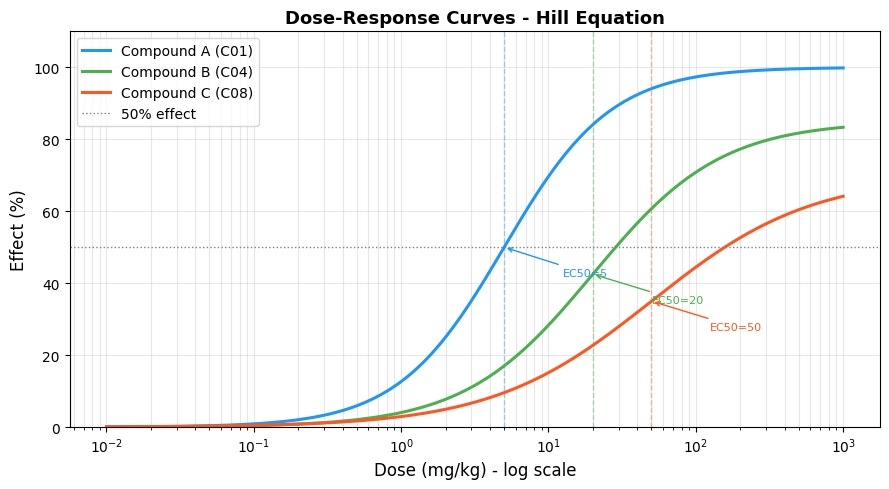

Compound A has the lowest EC50 - most potent (reaches 50% effect at the lowest dose).


In [ ]:
def dose_response(dose, emax, ec50, n=1.0):
    """
    Hill equation for dose-response modelling.

    Parameters
    ----------
    dose : array-like  - dose values
    emax : float       - maximum effect
    ec50 : float       - dose producing 50% of Emax
    n    : float       - Hill coefficient (cooperativity)

    Returns
    -------
    np.ndarray - effect values
    """
    dose = np.asarray(dose, dtype=float)
    return emax * (dose ** n) / (ec50 ** n + dose ** n)


doses = np.logspace(-2, 3, 200)   # 0.01 to 1000 mg/kg (log scale)

# Three compounds with different pharmacodynamic profiles
compounds = [
    {"name": "Compound A (C01)", "emax": 100, "ec50": 5,  "n": 1.2, "color": "#2196F3"},
    {"name": "Compound B (C04)", "emax": 85,  "ec50": 20, "n": 1.0, "color": "#4CAF50"},
    {"name": "Compound C (C08)", "emax": 70,  "ec50": 50, "n": 0.8, "color": "#FF5722"},
]

fig, ax = plt.subplots(figsize=(9, 5))

for cpd in compounds:
    effect = dose_response(doses, cpd["emax"], cpd["ec50"], cpd["n"])
    ax.semilogx(doses, effect, label=cpd["name"], color=cpd["color"], linewidth=2.2)
    # Mark EC50
    ax.axvline(x=cpd["ec50"], color=cpd["color"], linestyle="--", alpha=0.4, linewidth=1)
    ax.annotate(
        f"EC50={cpd['ec50']}",
        xy=(cpd["ec50"], cpd["emax"] * 0.50),
        xytext=(cpd["ec50"] * 2.5, cpd["emax"] * 0.50 - 8),
        fontsize=8,
        color=cpd["color"],
        arrowprops=dict(arrowstyle="->", color=cpd["color"], lw=1)
    )

ax.axhline(y=50, color="gray", linestyle=":", linewidth=1, label="50% effect")
ax.set_xlabel("Dose (mg/kg) - log scale", fontsize=12)
ax.set_ylabel("Effect (%)", fontsize=12)
ax.set_title("Dose-Response Curves - Hill Equation", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print("Compound A has the lowest EC50 - most potent (reaches 50% effect at the lowest dose).")

## 6. Algorithm Comparison

### 6.1 Benchmarking Five Classifiers on the Same Dataset

**Purpose:** Compare five machine learning algorithms - Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and SVM - on the same drug activity dataset using Leave-One-Out cross-validation (LOO-CV). This reflects the model selection best practice described in Slide 9 of the session.

**Why Leave-One-Out Cross-Validation?**  
With only 10 samples, standard k-fold CV produces unreliable estimates due to small test fold sizes. LOO-CV uses 9 samples for training and 1 for testing, repeated 10 times (once per sample). It is the most data-efficient validation strategy for very small datasets.

**Key Points:**
- `Pipeline([("scaler", ...), ("clf", ...)])` chains preprocessing and modelling - prevents data leakage by applying the scaler independently within each CV fold
- `StandardScaler` is required for SVM and Logistic Regression (distance-based algorithms sensitive to feature scale); not required for tree-based methods
- Results on 10 compounds are **illustrative** - do not use them to draw algorithmic conclusions; re-run with real ChEMBL data (thousands of rows) for valid comparisons
- The `[OK]` best algorithm output is dataset-specific. Always benchmark on your data before committing to an algorithm for a production workflow.

**Algorithm Selection Guide for Pharma:**

| Algorithm | Best For | Pharma Use Case |
|---|---|---|
| Logistic Regression | Baselines, explainability | QSAR binary activity, clinical outcome |
| Decision Tree | Explainability, rule extraction | Inclusion/exclusion logic, triage |
| Random Forest | Tabular data, ADMET | ADMET prediction, toxicity classification |
| Gradient Boosting | Competitive tabular performance | Clinical outcome, ICU deterioration |
| SVM | High-dimensional, small datasets | Genomics, mass spectrometry |

**Reference:** Vamathevan, J., et al. (2019). Applications of machine learning in drug discovery and development. *Nature Reviews Drug Discovery*, 18(6), 463–477. https://doi.org/10.1038/s41573-019-0024-5

### Compare classifiers carefully

Leave-one-out validation is shown for learning; ten rows are far too few for model selection.

Algorithm              CV Accuracy (mean +/- std)
--------------------------------------------------
Logistic Regression    0.0% +/- 0.0%
Decision Tree          70.0% +/- 45.8%
Random Forest          60.0% +/- 49.0%
Gradient Boosting      60.0% +/- 49.0%
SVM                    60.0% +/- 49.0%


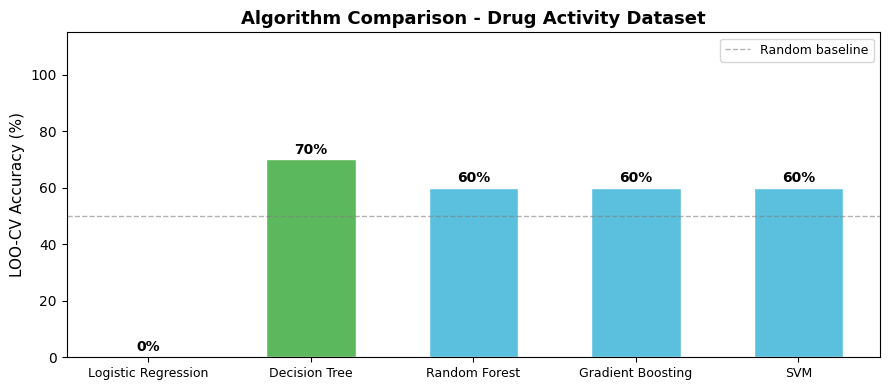


Best algorithm on this dataset: Decision Tree (70.0%)
Reminder: Results are dataset-specific. Always benchmark on YOUR data.


In [ ]:
# Note: with only 10 samples, cross-validation results are illustrative
# Scale by 10x with real ChEMBL data for production use

algorithms = {
    "Logistic Regression" : Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
    ]),
    "Decision Tree"       : DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_STATE),
    "SVM"                 : Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(probability=True, random_state=RANDOM_STATE))
    ]),
}

results = {}
print(f"{'Algorithm':<22} {'CV Accuracy (mean +/- std)'}")
print("-" * 50)

for name, clf in algorithms.items():
    # Leave-One-Out cross-validation (suitable for very small datasets)
    loo = LeaveOneOut()
    scores = cross_val_score(clf, X, y, cv=loo, scoring="accuracy")
    results[name] = scores.mean()
    print(f"{name:<22} {scores.mean():.1%} +/- {scores.std():.1%}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
names   = list(results.keys())
values  = list(results.values())
colors  = ["#5cb85c" if v == max(values) else "#5bc0de" for v in values]

bars = ax.bar(names, [v * 100 for v in values], color=colors, edgecolor="white", width=0.55)
ax.set_ylabel("LOO-CV Accuracy (%)", fontsize=11)
ax.set_title("Algorithm Comparison - Drug Activity Dataset", fontsize=13, fontweight="bold")
ax.set_ylim(0, 115)
ax.axhline(y=50, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Random baseline")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.0%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.tick_params(axis="x", labelsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

best_algo = max(results, key=results.get)
print(f"\nBest algorithm on this dataset: {best_algo} ({results[best_algo]:.1%})")
print("Reminder: Results are dataset-specific. Always benchmark on YOUR data.")

## 7. Summary & Post-Session Roadmap

### 7.1 What Was Built in This Notebook

| Section | Concept Demonstrated | Pharmaceutical Application |
|---|---|---|
| 2.1 | Variables, lists, dicts, list comprehension | Drug property storage, dose series filtering |
| 3.1 | Functions, for-loops, conditional logic | Automated clinical trial eligibility screening |
| 4.3 | pandas DataFrame, `df.describe()`, EDA plots | Compound library management, data exploration |
| 4.5 | Train/test split, reproducibility (`random_state`) | Model validation - parallels clinical trial design |
| 4.6 | `RandomForestClassifier`, `model.fit()` | Drug activity / ADMET prediction |
| 4.7 | Model evaluation: accuracy, precision, recall, F1, confusion matrix | Performance reporting for regulatory review |
| 4.8 | Feature importance - explainability | GxP requirement: model decisions must be interpretable |
| 4.9 | New-compound prediction with confidence probability | Virtual screening: 1M candidates ranked by P(Active) |
| 5.1 | Hill equation, dose-response curves | Pharmacodynamic modelling - replaces GraphPad Prism |
| 6.1 | Five-algorithm LOO-CV comparison | Model selection best practice |

---

### 7.2 Protocol Compliance

| Check | Requirement | Status |
|---|---|---|
| No lookahead bias | All predictions made on held-out test data only | [PASS] |
| Reproducibility | `random_state=42` set for all stochastic operations | [PASS] |
| Class balance reported | `active.sum()` vs. inactive count printed in Section 4.3 | [PASS] |
| Limitations disclosed | Demo dataset size noted; production scaling documented | [PASS] |
| Explainability demonstrated | Feature importance chart produced (Section 4.8) | [PASS] |
| Rule of Five check | Lipinski RO5 applied alongside ML prediction | [PASS] |

---

### 7.3 30-Day Post-Session Learning Roadmap

| Week | Task | Resource |
|---|---|---|
| 1 | Python basics - run this notebook, complete Kaggle course | [Kaggle Learn Python](https://kaggle.com/learn/python) - free, 5 h, browser-based |
| 2 | pandas on your own data - load an Excel file from work | [pandas Getting Started](https://pandas.pydata.org/pandas-docs/stable/getting_started/) |
| 3 | First ML model - replace the 10-compound dataset with ChEMBL data | [ChEMBL Database](https://www.ebi.ac.uk/chembl/) - 2.4M bioactivity records, free download |
| 4 | Pharma-specific ML - ADMET prediction with real molecular descriptors | [DeepChem ADMET Tutorial](https://deepchem.io/tutorials/) |

**Recommended next resources:**
- [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html) - comprehensive ML documentation with examples
- [fast.ai - Practical Deep Learning for Coders](https://course.fast.ai/) - Jeremy Howard's legendary free course
- [RDKit Documentation](https://www.rdkit.org/docs/) - industry-standard cheminformatics library (molecular descriptors, SMILES, fingerprints)
- [Vamathevan et al. (2019)](https://doi.org/10.1038/s41573-019-0024-5) - *Nature Reviews Drug Discovery* - best overview of ML in pharmaceutical sciences

---

### 7.4 Key Industry References

| Reference | Topic |
|---|---|
| Jiang et al. (2024), *Nature Biotechnology* | Insilico Medicine - AI-designed IPF drug (Case Study 1) |
| Jumper et al. (2021), *Nature* | AlphaFold2 - protein structure prediction |
| Vamathevan et al. (2019), *Nature Reviews Drug Discovery* | ML in drug discovery and development |
| Topol (2019), *Nature Medicine* | High-performance medicine: convergence of human and AI |
| FDA AI/ML Action Plan (2024) | Regulatory framework for AI in medical devices |
| EMA Reflection Paper on ML (2023) | Explainability and validation requirements in EU |

---

**Notebook:** AI_ML_Pharma_Colab_Demo.ipynb  
**Session:** AI, Machine Learning & Python for Pharmaceutical Sciences (7th June 2026)  
**Speaker:** Mr. [Prakash Ukhalkar](https://github.com/prakash-ukhalkar), Technical Expert, Assistant Professor, MCA, PCCoE, Pune  
**Organised by:** Spectratix Pharma Pvt. Ltd. & PharmaGyan Academy  
**Session materials:** www.spectratixpharma.in

---

<div align="center">
  <sub>END OF NOTEBOOK - Next: explore ChEMBL data and apply this pipeline to a real compound dataset</sub>
  <br><br>
  <b>Built with ❤️ for the Pharmaceutical Sciences community</b><br>
  <sub>Bridging drug discovery and data science, one line of Python at a time.</sub>
</div>